,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,0,Graduate,No,6000,2250.0,265.0,360.0,1.0,Semiurban,N
1,Male,Yes,0,Graduate,No,2958,2900.0,131.0,360.0,1.0,Semiurban,Y
2,Male,Yes,2,Graduate,No,6250,1695.0,210.0,360.0,1.0,Semiurban,Y
3,Male,Yes,0,Graduate,No,2083,3150.0,128.0,360.0,1.0,Semiurban,Y
4,Male,No,0,Graduate,No,4166,0.0,98.0,360.0,0.0,Semiurban,N


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,6000,2250.0,265.0,360.0,1.0,True,True,False,False,False,False,False,True,False,False
1,2958,2900.0,131.0,360.0,1.0,True,True,False,False,False,False,False,True,False,True
2,6250,1695.0,210.0,360.0,1.0,True,True,False,True,False,False,False,True,False,True
3,2083,3150.0,128.0,360.0,1.0,True,True,False,False,False,False,False,True,False,True
4,4166,0.0,98.0,360.0,0.0,True,False,False,False,False,False,False,True,False,False


acc 0.7373737373737373
              precision    recall  f1-score   support

      Denied       0.50      0.42      0.46        26
    Approved       0.81      0.85      0.83        73

    accuracy                           0.74        99
   macro avg       0.65      0.64      0.64        99
weighted avg       0.73      0.74      0.73        99



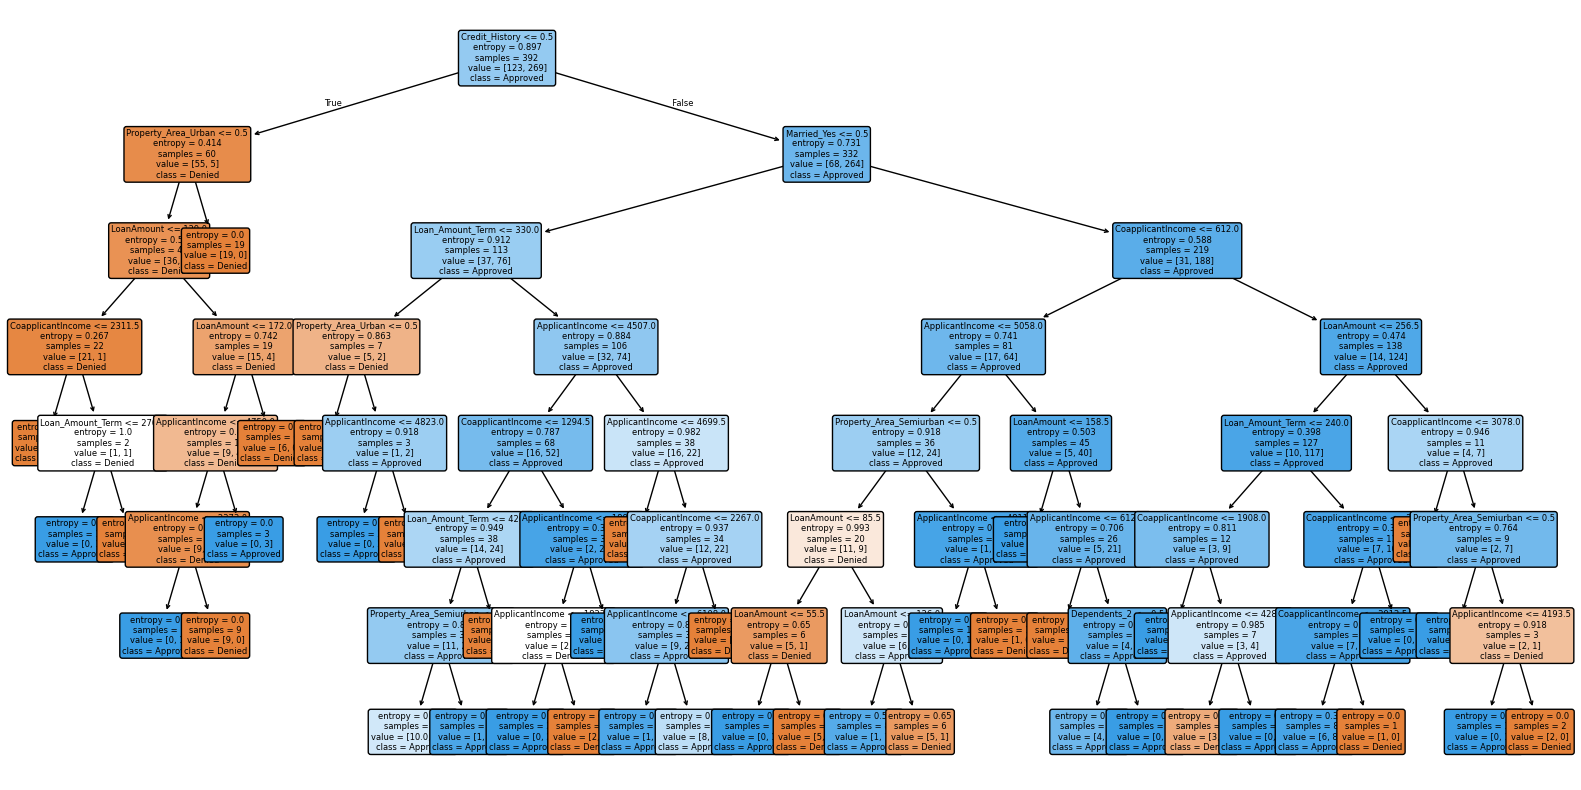

In [11]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree #학습된나무를그림으로보여줌
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

loan_data = pd.read_csv('../datasets/decision/train_loan_80.csv')
display(loan_data.head())
loan_encoded = pd.get_dummies(loan_data, drop_first=True)
display(loan_encoded.head())
x = loan_encoded.drop(columns=['Loan_Status_Y'])
y = loan_encoded['Loan_Status_Y']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
model = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=7)
model.fit(x_train, y_train)
pred = model.predict(x_test)
acc = accuracy_score(y_test, pred)
report = classification_report(y_test, pred, target_names=['Denied', 'Approved'])
print('acc', acc)
print(report)
import joblib
joblib.dump(model, 'loan_model.pkl')
joblib.dump(x.columns, 'model_features.pkl')
plt.figure(figsize = (20,10))
plot_tree(model, feature_names=x_train.columns, class_names=['Denied', 'Approved']
          ,filled=True, rounded=True, fontsize=6)
plt.show()